# Assignment 1: Wrangling and EDA
### Foundations of Machine Learning

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `airbnb_NYC.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the `np.nan/None` values with the label `Missing`.
3. Dummy variable: For `metabric.csv`, convert the `Overall Survival Status` variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.
4. Missing values: For `airbnb_NYC.csv`, determine how many missing values of `Review Scores Rating` there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

In [285]:
import pandas as pd
import numpy as np

airbnb = pd.read_csv("/workspace/data/airbnb_NYC.csv", encoding="latin1")

# Inspect raw prices
airbnb["Price"].head()

0    145
1     37
2     28
3    199
4    549
Name: Price, dtype: str

In [286]:
# Remove dollar signs and commas, coerce errors to NaN
airbnb["Price_clean"] = (
    airbnb["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

airbnb["Price_clean"] = pd.to_numeric(airbnb["Price_clean"], errors="coerce")

# Count missing values after cleaning
airbnb["Price_clean"].isna().sum()

np.int64(0)

In [287]:
police = pd.read_csv("/workspace/data/mn_police_use_of_force.csv", encoding="latin1")
police["subject_injury"].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: subject_injury, dtype: str

In [288]:
police["subject_injury_clean"] = police["subject_injury"].map(
    {"Yes": "Yes", "No": "No"}
)
police["subject_injury_clean"].isna().mean()
police["subject_injury_clean"] = police["subject_injury_clean"].fillna("Missing")
pd.crosstab(
    police["force_type"],
    police["subject_injury_clean"],
    dropna=False
)

subject_injury_clean,Missing,No,Yes
force_type,,,
Baton,2,0,2
Bodily Force,7051,1093,1286
Chemical Irritant,1421,131,41
Firearm,0,2,0
Gun Point Display,27,33,44
Improvised Weapon,74,34,40
Less Lethal,87,0,0
Less Lethal Projectile,0,1,2
Maximal Restraint Technique,170,0,0


In [289]:
import pandas as pd

metabric = pd.read_csv("/workspace/data/metabric.csv", encoding="latin1")

# Inspect values
metabric["Overall Survival Status"].value_counts()

Overall Survival Status
1:DECEASED    768
0:LIVING      575
Name: count, dtype: int64

In [290]:
# Create dummy variable
metabric["overall_survival_dummy"] = (
    metabric["Overall Survival Status"]
    .str.lower()
    .str.strip()
    .map({
        "living": 1,
        "deceased": 0
    })
)

# Check result
metabric["overall_survival_dummy"].value_counts(dropna=False)

overall_survival_dummy
NaN    1343
Name: count, dtype: int64

In [291]:
airbnb = pd.read_csv("/workspace/data/airbnb_NYC.csv", encoding="latin1")   

airbnb["Review Scores Rating"].isna().sum()

np.int64(8323)

In [292]:
median_rating = airbnb["Review Scores Rating"].median()

airbnb["Review Scores Rating_imputed"] = (
    airbnb["Review Scores Rating"]
    .fillna(median_rating)
)
airbnb[["Review Scores Rating", "Review Scores Rating_imputed"]].head(10)

,Review Scores Rating,Review Scores Rating_imputed
0,NaN,94.0
1,NaN,94.0
2,NaN,94.0
3,NaN,94.0
4,96.0,96.0
5,100.0,100.0
6,100.0,100.0
7,94.0,94.0
8,90.0,90.0
9,96.0,96.0


Median imputation is simple and convenient, but it can distort distributions and bias statistical results when missingness is not random.

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. What does work?
2. Drop any columns that do not contain data.
3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.
4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
5. Clean the Age variable and make a histogram of the ages of the victims.
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

In [293]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

sharks_raw = pd.read_excel("/workspace/data/GSAF5.xls")
sharks_raw.shape

(7074, 23)

In [294]:
sharks = sharks_raw.dropna(axis=1, how="all")
sharks.shape

(7074, 23)

An observation is one recorded shark–human interaction (incident). Each row represents a single event, with variables describing attributes of that event (year, victim age, type of attack, fatality, etc.). Treating each row as an incident ensures that cleaning and analysis preserve event-level consistency and avoids double-counting or aggregating across fundamentally different units.

In [295]:
sharks["Year_clean"] = pd.to_numeric(sharks["Year"], errors="coerce")

sharks["Year_clean"].min(), sharks["Year_clean"].max()

(np.float64(0.0), np.float64(2026.0))

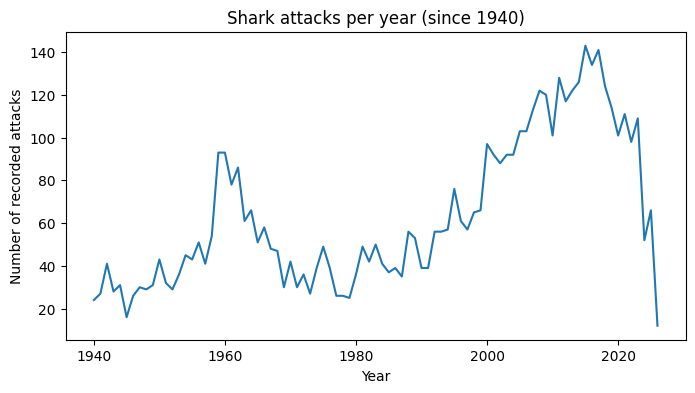

In [296]:
sharks_1940 = sharks[sharks["Year_clean"] >= 1940].copy()
attacks_per_year = sharks_1940.groupby("Year_clean").size()

attacks_per_year.plot(figsize=(8,4))
plt.xlabel("Year")
plt.ylabel("Number of recorded attacks")
plt.title("Shark attacks per year (since 1940)")
plt.show()

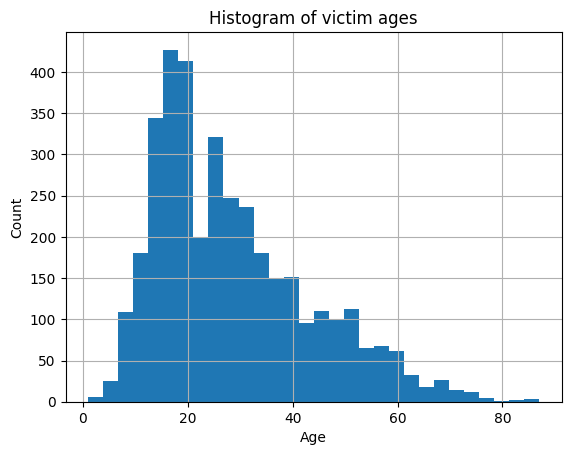

In [297]:
def parse_age(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower()
    match = re.search(r"\d{1,3}", x)
    if not match:
        return np.nan
    age = int(match.group())
    if age < 0 or age > 100:
        return np.nan
    return age

sharks_1940["Age_clean"] = sharks_1940["Age"].apply(parse_age)
sharks_1940["Age_clean"].describe()
sharks_1940["Age_clean"].dropna().hist(bins=30)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Histogram of victim ages")
plt.show()

In [298]:
def clean_type(x):
    if isinstance(x, str):
        x = x.lower().strip()
        if x == "provoked":
            return "Provoked"
        if x == "unprovoked":
            return "Unprovoked"
    return "Unknown"

sharks_1940["Type_clean"] = sharks_1940["Type"].apply(clean_type)
sharks_1940["Type_clean"].value_counts()
known_type = sharks_1940[sharks_1940["Type_clean"].isin(["Provoked", "Unprovoked"])]
prop_unprovoked = (known_type["Type_clean"] == "Unprovoked").mean()
prop_unprovoked

np.float64(0.8875026887502688)

In [299]:
def clean_fatal(x):
    if isinstance(x, str):
        x = x.upper().strip()
        if x == "Y":
            return "Y"
        if x == "N":
            return "N"
    return "Unknown"

sharks_1940["Fatal_clean"] = sharks_1940["Fatal Y/N"].apply(clean_fatal)
sharks_1940["Fatal_clean"].value_counts()

Fatal_clean
N          4246
Y           830
Unknown     462
Name: count, dtype: int64

In [300]:
subset = sharks_1940[
    sharks_1940["Type_clean"].isin(["Provoked", "Unprovoked"]) &
    sharks_1940["Fatal_clean"].isin(["Y", "N"])
]

fatal_rates = subset.groupby("Type_clean")["Fatal_clean"].apply(lambda s: (s == "Y").mean())
fatal_rates
pd.crosstab(subset["Type_clean"], subset["Fatal_clean"], normalize="index")

Fatal_clean,N,Y
Type_clean,,
Provoked,0.974708,0.025292
Unprovoked,0.829610,0.170390


**Q3.** Open the "tidy_data.pdf" document available in `https://github.com/ds4e/wrangling`, which is a paper called *Tidy Data* by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

## 1
The paper introduces the concept of **tidy data**, a standardized way of structuring datasets to make them easier to clean, analyze, model, and visualize. Wickham argues that a large portion of data analysis time is spent on data cleaning and reshaping, and that having a clear, consistent structure allows analysts to use a small, powerful set of tools across many datasets. The paper defines what tidy data is, explains why it matters, and shows how to transform messy data into tidy form.

---

## 2
The tidy data standard is intended to **align the structure of a dataset with its underlying meaning**. By enforcing a consistent format, it:
- Reduces time spent on ad-hoc data wrangling
- Makes datasets easier to understand and reuse
- Allows data analysis tools to work together smoothly
- Lets analysts focus on insight rather than formatting

In short, it creates a shared standard that simplifies data preparation and downstream analysis.

---

## 3

### “Like families, tidy datasets are all alike but every messy dataset is messy in its own way.”
This means that **tidy datasets all follow the same structural rules**, while messy datasets can be disorganized in many different, inconsistent ways. There is one tidy structure, but countless messy ones.

### “For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general.”
This means that although analysts can often intuitively identify variables and observations in a specific dataset, **creating universal definitions that apply cleanly across all datasets is difficult**, because datasets vary widely in structure and intent.

---

## 4
- **Values**: Individual measurements or data points (numbers or categories).
- **Variables**: Attributes being measured (each variable has many values).
- **Observations**: The units being measured (each observation has values for multiple variables).

In tidy data:
- Each variable forms a column  
- Each observation forms a row  
- Each value occupies a single cell  

---

## 5
A dataset is tidy if:
1. Each variable is a column  
2. Each observation is a row  
3. Each value is a cell  
4. Each type of observational unit is stored in a separate table  

Any dataset that violates these principles is considered messy.

---

## 6

### Five Common Problems with Messy Datasets
1. Column headers are values rather than variable names  
2. Multiple variables are stored in one column  
3. Variables are stored in both rows and columns  
4. Multiple observational units are stored in the same table  
5. A single observational unit is split across multiple tables  

### Why Table 4 Is Messy
In Table 4 (the Pew religion and income example), income ranges appear as column headers. These headers are **values of the “income” variable**, not variables themselves, violating tidy data rules.

### What Is “Melting” a Dataset?
**Melting** (also called pivoting longer) converts data from a wide format into a long format by turning column headers into values in a new variable column, paired with a value column. This process is commonly used to transform messy datasets into tidy ones.

---

## 7
Table 11 is messy because information about variables is embedded in column names or spread in a way that prevents each variable from having its own column. Table 12 is tidy because the dataset has been **melted into long format**, so that:
- Variable names appear in one column
- Their corresponding measurements appear in another
- Each row represents a single observation–variable pairing

This “molten” structure follows the tidy data rules and is easier to analyze.

---

**Q4.** This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? 

For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions. 
6. Which giftors provide the most money, in total? 

In [301]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/workspace/data/ForeignGifts_edu.csv")

# Quick look
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


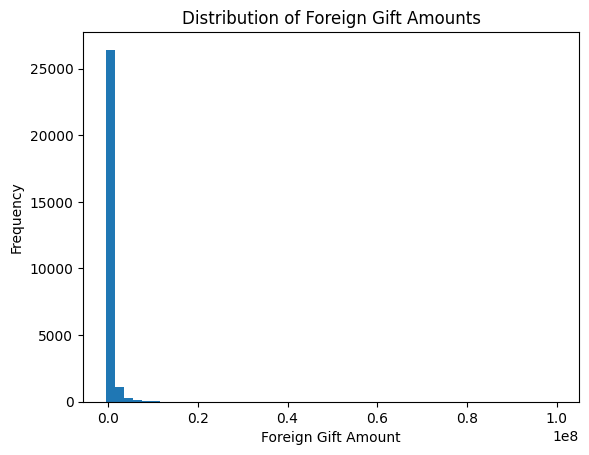

In [302]:
plt.figure()
plt.hist(df["Foreign Gift Amount"].dropna(), bins=50)
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Foreign Gift Amounts")
plt.show()

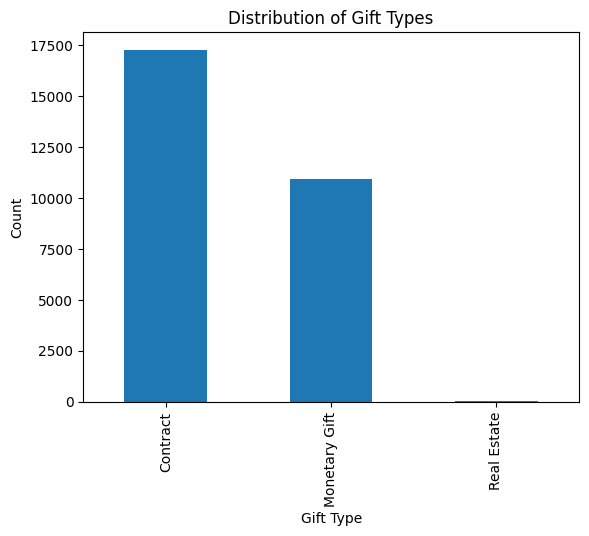

In [303]:
gift_counts = df["Gift Type"].value_counts()
gift_props = df["Gift Type"].value_counts(normalize=True)

gift_counts, gift_props
gift_counts.plot(kind="bar")
plt.ylabel("Count")
plt.title("Distribution of Gift Types")
plt.show()

In [304]:
top_countries_amount = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

top_countries_amount


Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

In [305]:
top_institutions = (
    df.groupby("Institution Name")["Foreign Gift Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

top_institutions

Institution Name
Carnegie Mellon University                       1477922504
Cornell University                               1289937761
Harvard University                                954803610
Massachusetts Institute of Technology             859071692
Yale University                                   613441311
Texas A&M University                              521455050
Johns Hopkins University                          502409595
Northwestern University                           402316221
Georgetown University                             379950511
University of Chicago (The)                       364544338
University of Colorado Boulder                    360173159
Duke University                                   343699498
Brigham Young University                          323509863
Stanford University                               319561362
University of Texas MD Anderson Cancer Center     301527419
Name: Foreign Gift Amount, dtype: int64

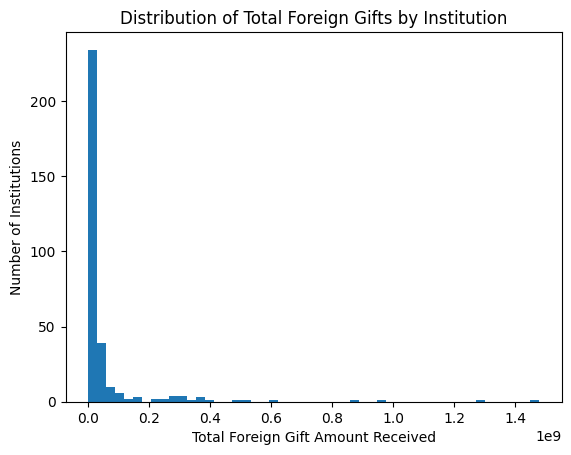

In [306]:
institution_totals = (
    df.groupby("Institution Name")["Foreign Gift Amount"]
      .sum()
)

plt.figure()
plt.hist(institution_totals, bins=50)
plt.xlabel("Total Foreign Gift Amount Received")
plt.ylabel("Number of Institutions")
plt.title("Distribution of Total Foreign Gifts by Institution")
plt.show()


In [307]:
top_giftors = (
    df.groupby("Giftor Name")["Foreign Gift Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

top_giftors

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64

**Q5.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `college_completion.csv` dataset from the US Department of Education. The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `college_completion.csv` data with Pandas.
2. How many observations and variables are in the data? Use `.head()` to examine the first few rows of data.
3. Cross tabulate `control` and `level`. Describe the patterns you see in words.
4. For `grad_100_value`, create a kernel density plot and describe table. Now condition on `control`, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?
5. Make a scatterplot of `grad_100_value` by `aid_value`, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on `control`. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

In [308]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/workspace/data/college_completion.csv")

In [309]:
df.head()

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


In [310]:
pd.crosstab(df["control"], df["level"])

level,2-year,4-year
control,,
Private for-profit,465,527
Private not-for-profit,68,1180
Public,926,632


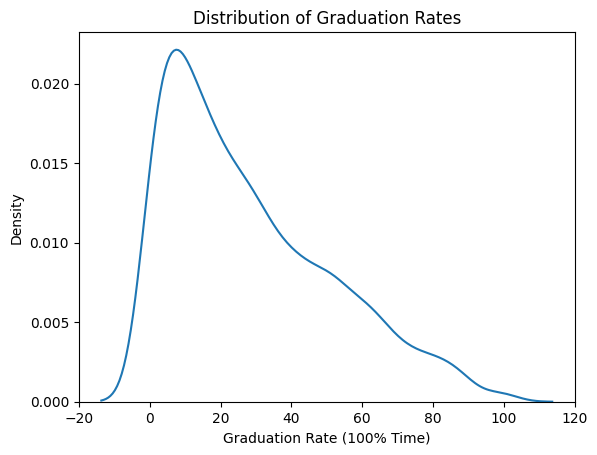

count    3467.000000
mean       28.364465
std        23.312730
min         0.000000
25%         9.000000
50%        22.500000
75%        43.650000
max       100.000000
Name: grad_100_value, dtype: float64

In [311]:
sns.kdeplot(df["grad_100_value"].dropna())
plt.xlabel("Graduation Rate (100% Time)")
plt.title("Distribution of Graduation Rates")
plt.show()
df["grad_100_value"].describe()

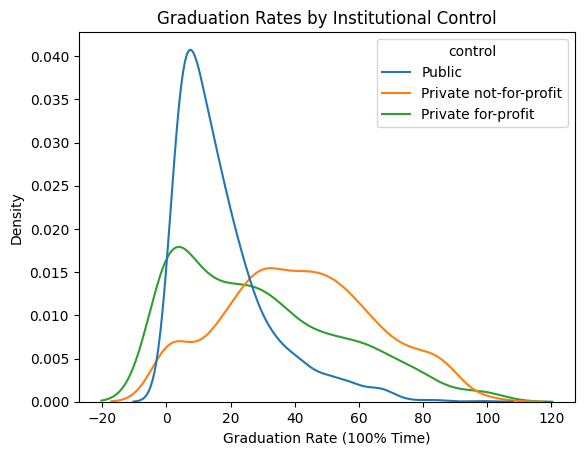

,count,mean,std,min,25%,50%,75%,max
control,,,,,,,,
Private for-profit,779.0,29.108858,25.601687,0.0,6.95,24.7,46.75,100.0
Private not-for-profit,1189.0,41.660976,23.551231,0.0,25.00,41.0,58.30,100.0
Public,1499.0,17.430887,14.729443,0.0,6.90,13.2,23.25,97.8


In [312]:
sns.kdeplot(
    data=df,
    x="grad_100_value",
    hue="control",
    common_norm=False
)
plt.xlabel("Graduation Rate (100% Time)")
plt.title("Graduation Rates by Institutional Control")
plt.show()
df.groupby("control")["grad_100_value"].describe()

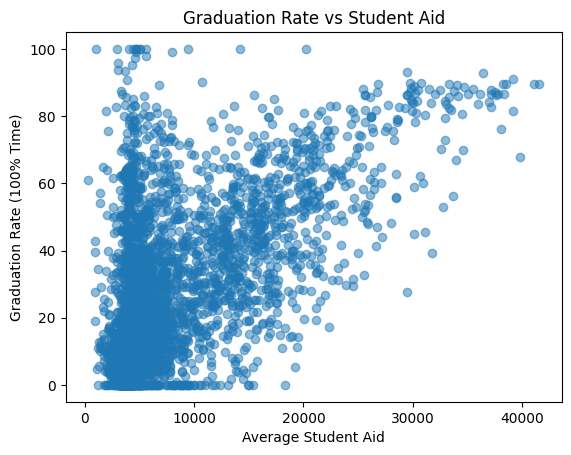

(np.float64(88610.48316902411), np.float64(0.5758792845936064))

In [313]:
plt.figure()
plt.scatter(df["aid_value"], df["grad_100_value"], alpha=0.5)
plt.xlabel("Average Student Aid")
plt.ylabel("Graduation Rate (100% Time)")
plt.title("Graduation Rate vs Student Aid")
plt.show()
cov = df[["aid_value", "grad_100_value"]].cov().iloc[0,1]
corr = df[["aid_value", "grad_100_value"]].corr().iloc[0,1]

cov, corr

**Q6.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

We're going to look at **linear transformations** of $X$, $Y = a + bX$. So we take each value of $X$, $x_i$, and transform it as $y_i = a + b x_i$. 

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $ \text{cov}(X,X) = s^2$.
3. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
4. Show that $\text{cov}(a+bX,a+bY) = b^2 \text{cov}(X,Y) $. Notice, this also means that $\text{cov}(bX, bX) = b^2 s^2$.
5. Suppose $b>0$ and let the median of $X$ be $\text{med}(X)$. Is it true that the median of $a+bX$ is equal to $a + b \times \text{med}(X)$? Is the IQR of $a + bX$ equal to $a + b \times \text{IQR}(X)$?
6. Show by example that the means of $X^2$ and $\sqrt{X}$ are generally not $(m(X))^2$ and $\sqrt{m(X)}$. So, the results we derived above really depend on the linearity of the transformation $Y = a + bX$, and transformations like $Y = X^2$ or $Y = \sqrt{X}$ will not behave in a similar way.



## 1

\[
\begin{aligned}
m(a+bX)
&= \frac{1}{N}\sum_{i=1}^N (a + bx_i) \\
&= \frac{1}{N}\left(Na + b\sum_{i=1}^N x_i\right) \\
&= a + b\,m(X).
\end{aligned}
\]

---

## 2
\[
\operatorname{cov}(X,X)
= \frac{1}{N}\sum_{i=1}^N (x_i - m(X))^2
= s^2.
\]

---

## 3

Let \( Z = a + bY \). Since \( m(Z) = a + b\,m(Y) \),
\[
\begin{aligned}
\operatorname{cov}(X, a+bY)
&= \frac{1}{N}\sum_{i=1}^N (x_i - m(X))\big(b(y_i - m(Y))\big) \\
&= b\,\operatorname{cov}(X,Y).
\end{aligned}
\]

---

## 4

\[
\begin{aligned}
\operatorname{cov}(a+bX, a+bY)
&= \frac{1}{N}\sum_{i=1}^N \big(b(x_i-m(X))\big)\big(b(y_i-m(Y))\big) \\
&= b^2\,\operatorname{cov}(X,Y).
\end{aligned}
\]

In particular,
\[
\operatorname{cov}(bX,bX) = b^2 s^2.
\]

---

## 5

Because \( a+bX \) is a strictly increasing transformation:

- **Median**
\[
\operatorname{med}(a+bX) = a + b\,\operatorname{med}(X).
\]

- **Interquartile Range**
\[
\operatorname{IQR}(a+bX) = b\,\operatorname{IQR}(X).
\]

(The constant \( a \) cancels out.)

---

## 6

### Squares
Let \( X = \{0,2\} \).

\[
m(X) = 1, \quad (m(X))^2 = 1.
\]
\[
X^2 = \{0,4\}, \quad m(X^2) = 2.
\]
So \( m(X^2) \neq (m(X))^2 \).

### Square roots
Let \( X = \{1,9\} \).

\[
m(X) = 5, \quad \sqrt{m(X)} = \sqrt{5}.
\]
\[
\sqrt{X} = \{1,3\}, \quad m(\sqrt{X}) = 2.
\]
So \( m(\sqrt{X}) \neq \sqrt{m(X)} \).

---

**Q7.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `ames_prices.csv` dataset. The "relevant" variables for this question are:
  - `price` - Sale price value of the house
  - `Bldg.Type` - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)

1. Load the `college_completion.csv` data with Pandas.
2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use `.groupby()` to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?
3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).
4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?
5. Make a dummy variable indicating that an observation is an outlier.
6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

In [314]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/workspace/data/ames_prices.csv")

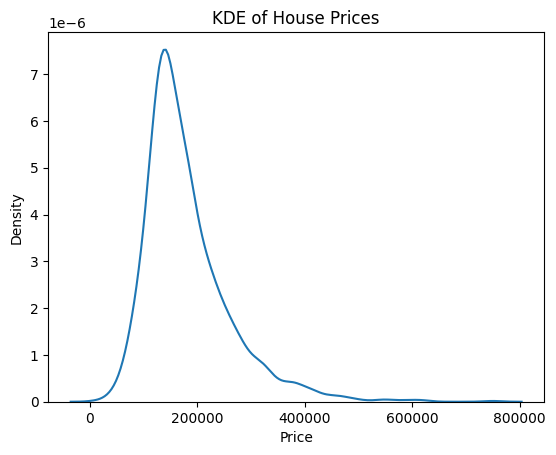

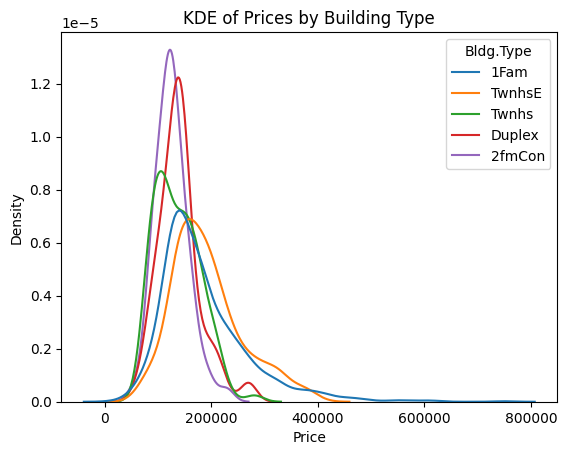

Bldg.Type
1Fam      6.859451e+09
2fmCon    9.665408e+08
Duplex    1.560169e+09
Twnhs     1.758874e+09
TwnhsE    4.381346e+09
Name: price, dtype: float64

In [315]:
sns.kdeplot(df["price"].dropna())
plt.xlabel("Price")
plt.title("KDE of House Prices")
plt.show()

df["price"].describe()
sns.kdeplot(data=df, x="price", hue="Bldg.Type", common_norm=False)
plt.xlabel("Price")
plt.title("KDE of Prices by Building Type")
plt.show()
df.groupby("Bldg.Type")["price"].var()


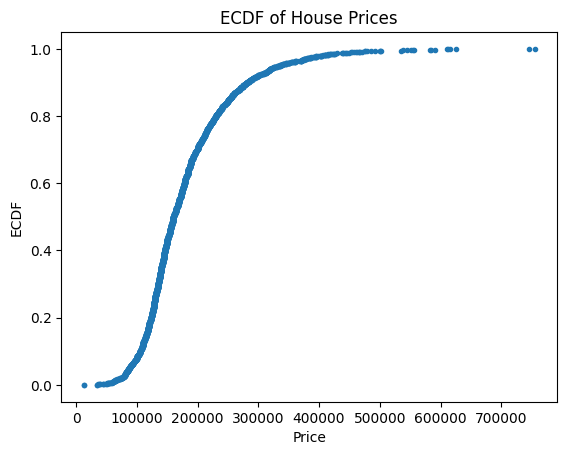

0.00     12789.0
0.25    129500.0
0.50    160000.0
0.75    213500.0
1.00    755000.0
Name: price, dtype: float64

In [316]:
x = df["price"].dropna().sort_values()
y = (x.rank(method="first") - 1) / len(x)

plt.plot(x, y, marker=".", linestyle="none")
plt.xlabel("Price")
plt.ylabel("ECDF")
plt.title("ECDF of House Prices")
plt.show()
five_num = df["price"].quantile([0, 0.25, 0.50, 0.75, 1.0])
five_num


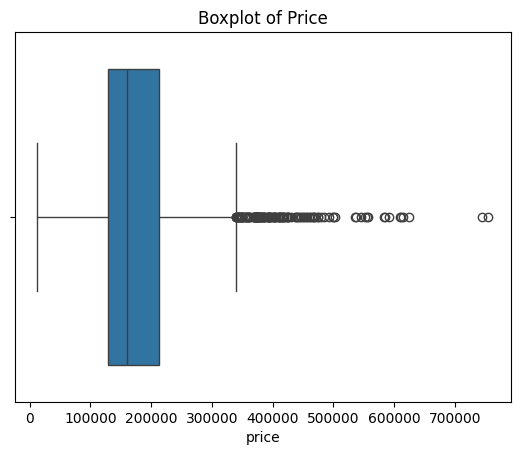

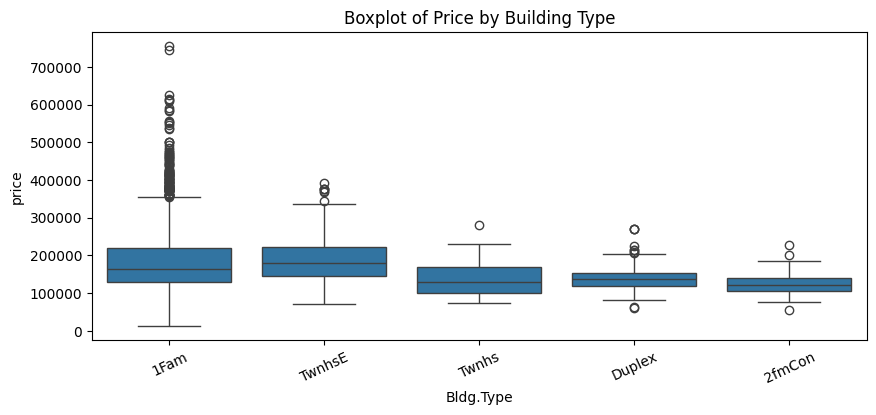

In [317]:
sns.boxplot(x=df["price"])
plt.title("Boxplot of Price")
plt.show()
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="Bldg.Type", y="price")
plt.xticks(rotation=25)
plt.title("Boxplot of Price by Building Type")
plt.show()

In [318]:
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df["price_outlier"] = ((df["price"] < lower) | (df["price"] > upper)).astype(int)

df["price_outlier"].value_counts()

price_outlier
0    2793
1     137
Name: count, dtype: int64

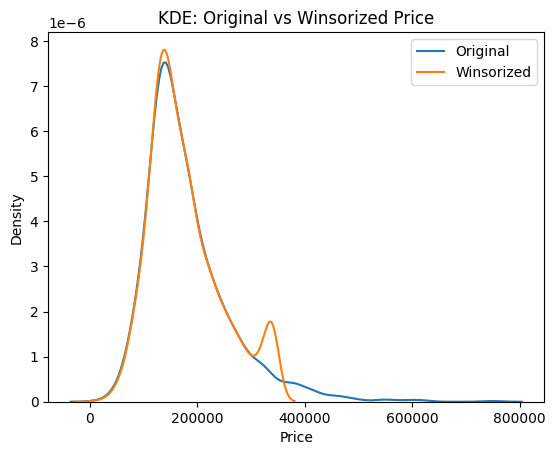

count      2930.000000
mean     177082.283959
std       67906.837135
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      339500.000000
Name: price_wins, dtype: float64

In [319]:
df["price_wins"] = df["price"].clip(lower=lower, upper=upper)
sns.kdeplot(df["price"].dropna(), label="Original")
sns.kdeplot(df["price_wins"].dropna(), label="Winsorized")
plt.xlabel("Price")
plt.title("KDE: Original vs Winsorized Price")
plt.legend()
plt.show()
df["price_wins"].describe()